# 02 — LSM age × sex marginal, with comparison to project stub

Builds the survey-weighted age × sex marginal of LSM from the parquet written by notebook 01, and compares it to the project's current stub (`mean = 6 kPa`, `SD = 4 kPa`) used in the project repo's `data_values.py`.

Mirrors the layout of `nhanes_lpa_distribution/02_lpa_marginal.ipynb`. The expectation here — informed by clinical observation that fibrosis accumulates with age and that men carry higher MASLD prevalence — is that age × sex variation will be **larger** than what we saw for Lp(a) (which was almost flat).

## What we'll show

1. **Overall distribution shape** — histogram + heavy-tail summary stats; share above F4 cutoff (12.5 kPa).
2. **Age × sex marginal** — survey-weighted mean and median with 95 % CIs from a paired-PSU jackknife, plotted in the same age-profile layout as the lpa notebook.
3. **Trial-band slice (65–80)** — mean / median / SD that we'd plug into `LIVER_STIFFNESS_*_KPA_STUB`.
4. **F4-share by age × sex** — the load-bearing quantity for the project (the F4 share drives cirrhosis EMR routing).
5. **Comparison vs the project stub + recommendation.**

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

DATA_DIR = Path(os.path.abspath(os.path.join('..', 'data')))
DERIVED_DIR = DATA_DIR / 'derived'
df = pd.read_parquet(DERIVED_DIR / 'nhanes_p_lux.parquet')
print(f'rows in P_LUX merge: {len(df):,}')

ana = df[
    df['exam_complete']
    & df['LSM_KPA'].notna()
    & df['WTMECPRP'].fillna(0).gt(0)
].copy()
adults = ana[ana['age_years'] >= 20].copy()
print(f'  MEC-examined adults 20+ with LSM: {len(adults):,}')

PROJECT_MEAN = 6.0  # data_values.LIVER_STIFFNESS_MEAN_KPA_STUB
PROJECT_SD   = 4.0  # data_values.LIVER_STIFFNESS_SD_KPA_STUB
F4_CUTOFF    = 12.5

rows in P_LUX merge: 15,560
  MEC-examined adults 20+ with LSM: 7,396


In [2]:
def w_mean(y, w):
    return np.average(y, weights=w)

def w_var(y, w):
    m = w_mean(y, w)
    return np.average((y - m) ** 2, weights=w)

def w_quantile(y, w, q):
    order = np.argsort(y)
    y_s, w_s = y[order], w[order]
    cw = np.cumsum(w_s) / w_s.sum()
    return float(np.interp(q, cw, y_s))

y = adults['LSM_KPA'].values
w = adults['WTMECPRP'].values

stats_summary = {
    'n':            len(adults),
    'mean':         w_mean(y, w),
    'median':       w_quantile(y, w, 0.50),
    'SD':           np.sqrt(w_var(y, w)),
    'P10':          w_quantile(y, w, 0.10),
    'P25':          w_quantile(y, w, 0.25),
    'P75':          w_quantile(y, w, 0.75),
    'P90':          w_quantile(y, w, 0.90),
    'P99':          w_quantile(y, w, 0.99),
    'max':          float(y.max()),
    'share ≥ 12.5': w[y >= F4_CUTOFF].sum() / w.sum(),
    'share ≥  9.5': w[y >= 9.5].sum() / w.sum(),
}
for k, v in stats_summary.items():
    if isinstance(v, float):
        print(f'  {k:<14} {v:.3f}')
    else:
        print(f'  {k:<14} {v:,}')
print()
print(f'Project stub: mean = {PROJECT_MEAN} kPa, SD = {PROJECT_SD} kPa')

  n              7,396
  mean           5.719
  median         4.900
  SD             4.419
  P10            3.400
  P25            4.100
  P75            6.100
  P90            7.800
  P99            21.390
  max            75.000
  share ≥ 12.5   0.030
  share ≥  9.5   0.056

Project stub: mean = 6.0 kPa, SD = 4.0 kPa


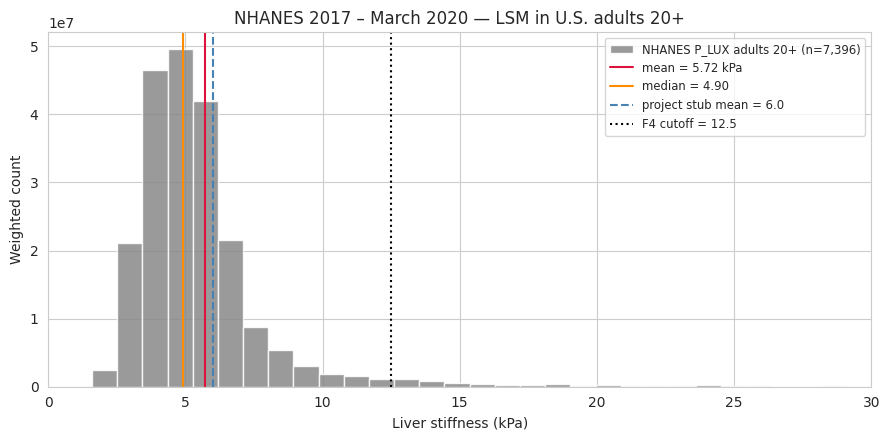

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(y, bins=80, weights=w, color='#888', alpha=0.85,
        label=f'NHANES P_LUX adults 20+ (n={len(adults):,})')
ax.axvline(stats_summary['mean'], color='crimson',
           label=f"mean = {stats_summary['mean']:.2f} kPa")
ax.axvline(stats_summary['median'], color='darkorange',
           label=f"median = {stats_summary['median']:.2f}")
ax.axvline(PROJECT_MEAN, color='steelblue', linestyle='--',
           label=f'project stub mean = {PROJECT_MEAN}')
ax.axvline(F4_CUTOFF, color='black', linestyle=':',
           label=f'F4 cutoff = {F4_CUTOFF}')
ax.set_xlabel('Liver stiffness (kPa)')
ax.set_ylabel('Weighted count')
ax.set_xlim(0, 30)
ax.set_title('NHANES 2017 – March 2020 — LSM in U.S. adults 20+')
ax.legend(loc='upper right', fontsize='small')
fig.tight_layout()
plt.show()

## 2. Age × sex marginal

Per-(sex, 5-year-age-band) weighted mean and median of LSM, with 95 % CIs from a paired-PSU jackknife (continuous-NHANES `SDMVSTRA` × `SDMVPSU`). Same layout as the lpa notebook for direct visual comparison.

In [4]:
def paired_jackknife(df_sub, statistic):
    """Paired-PSU jackknife SE for a survey-weighted statistic.

    Each masked stratum has two pseudo-PSUs in continuous NHANES.
    Iterate strata: zero out one PSU, double the other, recompute,
    accumulate squared deviations from the full-sample value.
    """
    if len(df_sub) == 0:
        return np.nan, np.nan
    y = df_sub['LSM_KPA'].values
    w = df_sub['WTMECPRP'].values
    s = df_sub['SDMVSTRA'].astype(int).values
    p = df_sub['SDMVPSU'].astype(int).values
    theta = statistic(y, w)
    var_sum = 0.0
    for stratum in np.unique(s):
        in_str = s == stratum
        psus_in = np.unique(p[in_str])
        if len(psus_in) < 2:
            continue
        for psu in psus_in:
            w_r = w.copy()
            mask_in = in_str & (p == psu)
            mask_other = in_str & (p != psu)
            w_r[mask_in] = 0.0
            w_r[mask_other] = w_r[mask_other] * 2.0
            if w_r.sum() <= 0:
                continue
            theta_r = statistic(y, w_r)
            var_sum += (theta_r - theta) ** 2
    return theta, np.sqrt(var_sum)

def stratum_summary(df_sub):
    mean, mean_se = paired_jackknife(df_sub, w_mean)
    med, med_se = paired_jackknife(df_sub, lambda y, w: w_quantile(y, w, 0.50))
    return {
        'n': len(df_sub),
        'mean': mean,
        'mean_se': mean_se,
        'median': med,
        'median_se': med_se,
        'mean_lo': mean - 1.96 * mean_se,
        'mean_hi': mean + 1.96 * mean_se,
        'median_lo': med - 1.96 * med_se,
        'median_hi': med + 1.96 * med_se,
    }

In [5]:
AGE_BINS = [20, 30, 40, 50, 60, 70, 80, 90]
AGE_LABELS = [f'{a}-{AGE_BINS[i+1]-1}' for i, a in enumerate(AGE_BINS[:-1])]
adults['age_group'] = pd.cut(adults['age_years'], bins=AGE_BINS,
                              right=False, labels=AGE_LABELS)
rows = []
for sex in ['Female', 'Male']:
    for age_lbl in AGE_LABELS:
        sub = adults[(adults['sex'] == sex) & (adults['age_group'] == age_lbl)]
        d = stratum_summary(sub)
        d.update({'sex': sex, 'age_group': age_lbl})
        rows.append(d)
table = pd.DataFrame(rows)
table

,n,mean,mean_se,median,median_se,mean_lo,mean_hi,median_lo,median_hi,sex,age_group
0,550,4.687910,0.192101,4.500000,0.177122,4.311392,5.064428,4.152841,4.847159,Female,20-29
1,611,5.370926,0.472067,4.500000,0.316228,4.445675,6.296177,3.880194,5.119806,Female,30-39
2,604,4.915434,0.154464,4.400000,0.449219,4.612684,5.218183,3.519531,5.280469,Female,40-49
3,689,5.667411,0.323168,4.900000,0.349160,5.034003,6.300820,4.215647,5.584353,Female,50-59
4,721,5.532427,0.246231,4.755617,0.285137,5.049814,6.015039,4.196748,5.314485,Female,60-69
5,374,5.684430,0.219268,5.000000,0.468773,5.254665,6.114194,4.081206,5.918794,Female,70-79
6,190,5.460888,0.140003,4.900000,0.062950,5.186481,5.735295,4.776618,5.023382,Female,80-89
7,560,6.026598,0.459733,5.200000,0.145642,5.125522,6.927675,4.914543,5.485457,Male,20-29
8,540,5.694861,0.316521,5.200000,0.302249,5.074479,6.315243,4.607591,5.792409,Male,30-39
9,590,6.032036,0.452693,5.300000,0.175370,5.144758,6.919313,4.956275,5.643725,Male,40-49


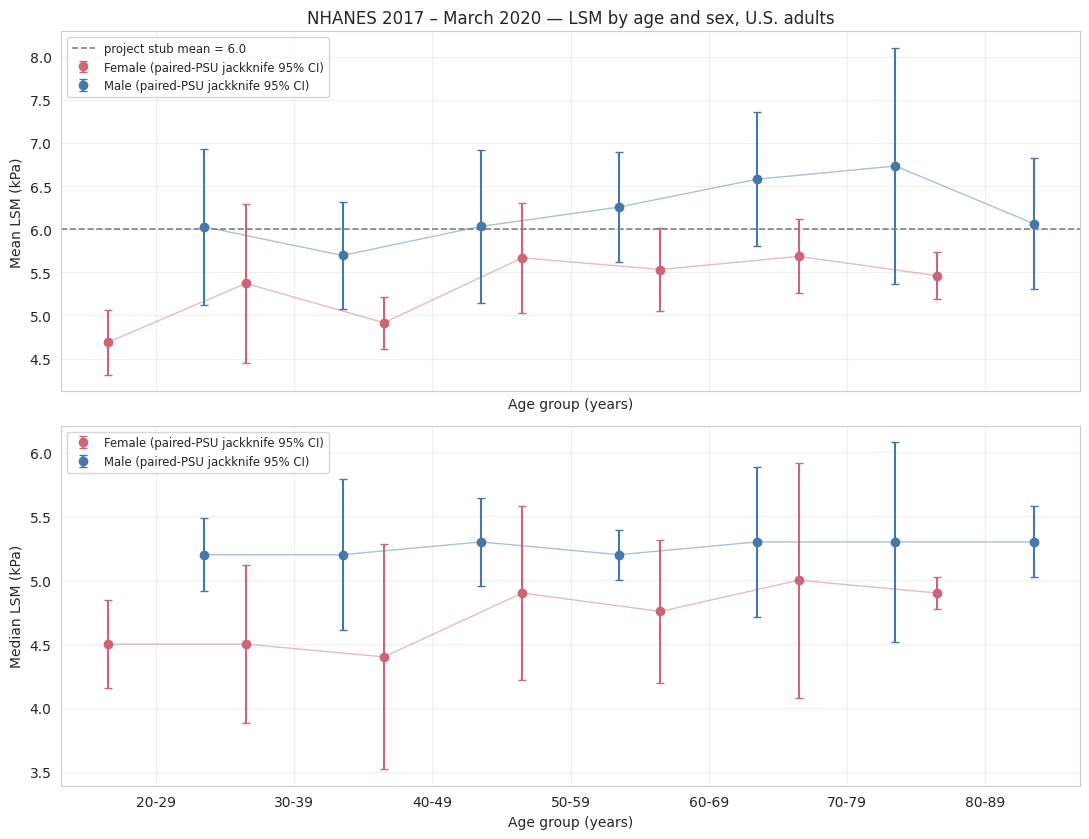

In [6]:
sex_colors = {'Female': '#cc6677', 'Male': '#4477aa'}
fig, axes = plt.subplots(2, 1, figsize=(11, 8.5), sharex=True)
ages = AGE_LABELS
age_pos = {a: i for i, a in enumerate(ages)}
spread = 0.35

for ax, stat, lo_col, hi_col, label in (
    (axes[0], 'mean',   'mean_lo',   'mean_hi',   'Mean LSM (kPa)'),
    (axes[1], 'median', 'median_lo', 'median_hi', 'Median LSM (kPa)'),
):
    for sex_idx, sex in enumerate(['Female', 'Male']):
        sub = table[table['sex'] == sex].sort_values(
            'age_group', key=lambda c: c.map(age_pos)
        )
        x = sub['age_group'].map(age_pos) + (sex_idx - 0.5) * spread * 2
        ax.errorbar(
            x, sub[stat],
            yerr=[sub[stat] - sub[lo_col], sub[hi_col] - sub[stat]],
            fmt='o', capsize=3, color=sex_colors[sex],
            label=f'{sex} (paired-PSU jackknife 95% CI)',
        )
        ax.plot(x, sub[stat], '-', color=sex_colors[sex], alpha=0.45,
                linewidth=1)
    if stat == 'mean':
        ax.axhline(PROJECT_MEAN, color='gray', linestyle='--',
                   linewidth=1.2,
                   label=f'project stub mean = {PROJECT_MEAN}')
    ax.set_xticks(range(len(ages)))
    ax.set_xticklabels(ages)
    ax.set_xlabel('Age group (years)')
    ax.set_ylabel(label)
    ax.legend(fontsize='small')
    ax.grid(True, alpha=0.3)

axes[0].set_title('NHANES 2017 – March 2020 — LSM by age and sex, U.S. adults')
fig.tight_layout()
plt.show()

## 3. Trial-band slice (age 65–80)

If we go with a single-scalar approach, the trial-band 65–80 mean and SD are the right inputs. Compute with `WTMECPRP` + paired-PSU jackknife.

In [7]:
trial = adults[(adults['age_years'] >= 65) & (adults['age_years'] <= 80)]
print(f'Trial-band sample (age 65-80, both sexes): n = {len(trial):,}')

trial_summary = stratum_summary(trial)
y_t = trial['LSM_KPA'].values
w_t = trial['WTMECPRP'].values
trial_summary['SD'] = np.sqrt(w_var(y_t, w_t))
trial_summary['share_F4'] = w_t[y_t >= F4_CUTOFF].sum() / w_t.sum()
for k in ['n', 'mean', 'mean_se', 'mean_lo', 'mean_hi',
         'median', 'median_se', 'median_lo', 'median_hi', 'SD', 'share_F4']:
    val = trial_summary[k]
    if isinstance(val, float):
        print(f'  {k:<12} {val:.3f}')
    else:
        print(f'  {k:<12} {val:,}')
print()
print('By sex within the trial band:')
by_sex = []
for sex in ['Female', 'Male']:
    sub = trial[trial['sex'] == sex]
    s = stratum_summary(sub)
    s['SD'] = np.sqrt(w_var(sub['LSM_KPA'].values, sub['WTMECPRP'].values))
    s['share_F4'] = sub['WTMECPRP'][sub['LSM_KPA'] >= F4_CUTOFF].sum() / sub['WTMECPRP'].sum()
    s['sex'] = sex
    by_sex.append(s)
print(pd.DataFrame(by_sex)[['sex', 'n', 'mean', 'median', 'SD', 'share_F4']].round(3))

Trial-band sample (age 65-80, both sexes): n = 1,787
  n            1,787
  mean         6.053
  mean_se      0.288
  mean_lo      5.489
  mean_hi      6.617
  median       5.100
  median_se    0.200
  median_lo    4.708
  median_hi    5.492
  SD           4.648
  share_F4     0.041

By sex within the trial band:
      sex    n   mean  median     SD  share_F4
0  Female  870  5.653     4.9  3.502     0.028
1    Male  917  6.527     5.3  5.682     0.057


## 4. F4 share by age × sex

The F4 share (LSM ≥ 12.5 kPa) by age × sex is the load-bearing quantity for the project's threshold-EMR routing — it's what determines the fraction of simulants getting cirrhosis EMR vs MASLD EMR. The project stub (mean=6, SD=4 lognormal) was tuned to ~7 % F4 share globally; let's see how that breaks down.

   sex age_group   n  share_F4
Female     20-29 550     0.004
Female     30-39 611     0.022
Female     40-49 604     0.012
Female     50-59 689     0.037
Female     60-69 721     0.030
Female     70-79 374     0.025
Female     80-89 190     0.019
  Male     20-29 560     0.029
  Male     30-39 540     0.019
  Male     40-49 590     0.024
  Male     50-59 599     0.055
  Male     60-69 745     0.067
  Male     70-79 403     0.060
  Male     80-89 220     0.032


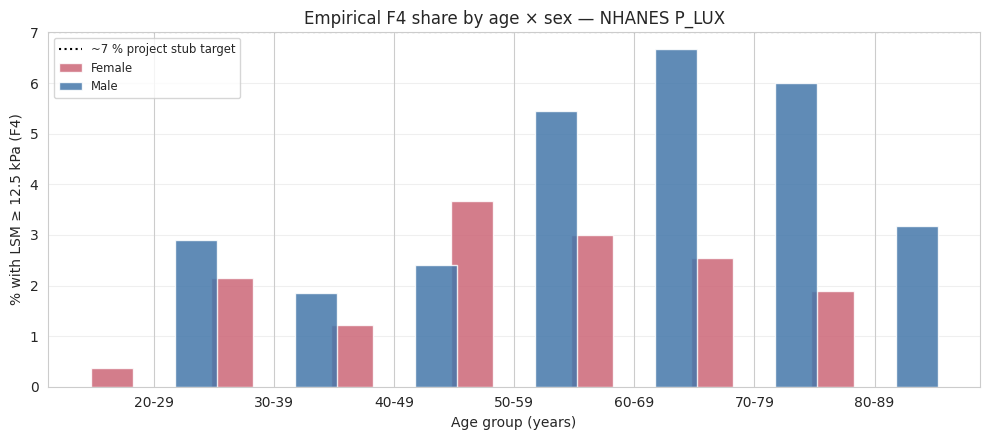

In [8]:
rows = []
for sex in ['Female', 'Male']:
    for age_lbl in AGE_LABELS:
        sub = adults[(adults['sex'] == sex) & (adults['age_group'] == age_lbl)]
        if len(sub) == 0:
            continue
        ws = sub['WTMECPRP'].values
        ys = sub['LSM_KPA'].values
        share = ws[ys >= F4_CUTOFF].sum() / ws.sum()
        rows.append({'sex': sex, 'age_group': age_lbl, 'n': len(sub), 'share_F4': share})
share_table = pd.DataFrame(rows)
print(share_table.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4.5))
for sex_idx, sex in enumerate(['Female', 'Male']):
    sub = share_table[share_table['sex'] == sex].sort_values(
        'age_group', key=lambda c: c.map(age_pos)
    )
    x = sub['age_group'].map(age_pos) + (sex_idx - 0.5) * spread * 2
    ax.bar(x, 100 * sub['share_F4'], width=0.35, color=sex_colors[sex],
           label=sex, alpha=0.85)
ax.axhline(7.0, color='black', linestyle=':',
           label='~7 % project stub target')
ax.set_xticks(range(len(ages)))
ax.set_xticklabels(ages)
ax.set_xlabel('Age group (years)')
ax.set_ylabel('% with LSM ≥ 12.5 kPa (F4)')
ax.set_title('Empirical F4 share by age × sex — NHANES P_LUX')
ax.legend(fontsize='small')
ax.grid(True, alpha=0.3, axis='y')
fig.tight_layout()
plt.show()

## 5. Comparison vs the project stub + recommendation

Walk the project stub (`mean = 6, SD = 4`) through the cells above. The decision criteria are the same as for Lp(a):

- between-cell SD of cell means **vs** median within-cell SD,
- max difference between any two cell means / medians,
- and (project-specific to LSM) the F4-share dispersion across cells.

In [9]:
table['within_sd'] = np.nan
for i, row in table.iterrows():
    sub = adults[(adults['sex'] == row['sex']) & (adults['age_group'] == row['age_group'])]
    if len(sub) > 0:
        table.loc[i, 'within_sd'] = np.sqrt(w_var(sub['LSM_KPA'].values, sub['WTMECPRP'].values))

between_sd_mean   = table['mean'].std()
median_within_sd  = table['within_sd'].median()
max_diff_in_means = table['mean'].max() - table['mean'].min()
max_diff_in_medians = table['median'].max() - table['median'].min()

print(f'Between-cell SD of cell means:    {between_sd_mean:.2f} kPa')
print(f'Median within-cell SD:            {median_within_sd:.2f} kPa')
print(f'  → between/within ratio:         {between_sd_mean / median_within_sd:.2f}')
print()
print(f'Max diff between any two cell means:   {max_diff_in_means:.2f} kPa')
print(f'Max diff between any two cell medians: {max_diff_in_medians:.2f} kPa')
print()
f4_min = share_table['share_F4'].min()
f4_max = share_table['share_F4'].max()
print(f'F4-share range across cells:       {100*f4_min:.1f} % – {100*f4_max:.1f} %')
print(f'  → ratio max / min:               {f4_max / max(f4_min, 1e-6):.1f}')
print()
print('Trial-band 65-80 single-scalar candidates (vs project stub mean=6, SD=4):')
print(f"  LIVER_STIFFNESS_MEAN_KPA_STUB = {trial_summary['mean']:.2f}")
print(f"  LIVER_STIFFNESS_SD_KPA_STUB   = {trial_summary['SD']:.2f}")
print(f'  empirical F4 share in trial band: {100*trial_summary["share_F4"]:.1f} %')
print()
print('Recommendation criterion:')
if between_sd_mean / median_within_sd > 0.20 or max_diff_in_means > 1.5:
    print('  → between-cell variation is non-trivial. Single scalar is a')
    print('    weak approximation. Either (a) update the trial-band scalar,')
    print('    or (b) wire age × sex stratified means into the loader.')
else:
    print('  → between-cell variation is small relative to within-cell. A')
    print('    single scalar update (trial-band mean / SD) is adequate.')

Between-cell SD of cell means:    0.57 kPa
Median within-cell SD:            4.19 kPa
  → between/within ratio:         0.14

Max diff between any two cell means:   2.04 kPa
Max diff between any two cell medians: 0.90 kPa

F4-share range across cells:       0.4 % – 6.7 %
  → ratio max / min:               17.8

Trial-band 65-80 single-scalar candidates (vs project stub mean=6, SD=4):
  LIVER_STIFFNESS_MEAN_KPA_STUB = 6.05
  LIVER_STIFFNESS_SD_KPA_STUB   = 4.65
  empirical F4 share in trial band: 4.1 %

Recommendation criterion:
  → between-cell variation is non-trivial. Single scalar is a
    weak approximation. Either (a) update the trial-band scalar,
    or (b) wire age × sex stratified means into the loader.


## Caveats

- **Single combined cycle (2017 – March 2020).** A 2021–2023 cycle (`LUX_L`) has more LSM measurements and could be combined for additional N. Combining requires NCHS analytic-guideline weight scaling.
- **MEC-only and complete-exam-only.** `WTMECPRP` is the right weight; `LUAXSTAT == 1` excludes incomplete exams. Roughly 7 % of MEC-examined adults had an invalid or missing FibroScan; that selection bias isn't corrected here.
- **Topcoded age 80.** `RIDAGEYR` topcodes at 80 in continuous NHANES, so the trial-band slice (65–80) includes some 80+ adults who are all coded as 80. Effect on the trial-band scalar is small.
- **F4 cutoff.** Per Castera/EASL guidance the F4-equivalent cutoff is 12.5 kPa. Some literature uses 11.0 or 14.0 kPa. The project's choice (12.5) is documented in `data_values.py`.